In [1]:
# !pip install -q kaggle

# **Edge AI**

*This project aims at classifying trash into different classes*
*The dataset was obtained from (https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)*

## **Import Libraries**

In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Import Dataset from Kaggle**

In [4]:
# Upload Kaggle API Token `kaggle.json`
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\r\n    "username": "chemutai254",\r\n    "key": "KGAT_7ba003da716e2cb2b3d9375e46ebcdae"\r\n}'}

In [5]:
# Configure the token
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
# Download the dataset
!kaggle datasets download -d farzadnekouei/trash-type-image-dataset


Dataset URL: https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset
License(s): unknown
  0% 0.00/40.9M [00:00<?, ?B/s]
100% 40.9M/40.9M [00:00<00:00, 1.24GB/s]


In [7]:
# Unzip the downloaded dataset
!unzip trash-type-image-dataset.zip -d /content/trash_dataset

Archive:  trash-type-image-dataset.zip
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_001.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_002.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_003.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_004.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_005.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_006.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_007.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_008.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_009.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/cardboard/cardboard_010.jpg  
  inflating: /content/trash_dataset/TrashType_Image_Dataset/c

In [8]:
# Inspect the structure
import os
for root, dirs, files in os.walk("/content/trash_dataset"):
    print(root, len(files), "files")

/content/trash_dataset 0 files
/content/trash_dataset/TrashType_Image_Dataset 0 files
/content/trash_dataset/TrashType_Image_Dataset/cardboard 403 files
/content/trash_dataset/TrashType_Image_Dataset/glass 501 files
/content/trash_dataset/TrashType_Image_Dataset/metal 410 files
/content/trash_dataset/TrashType_Image_Dataset/paper 594 files
/content/trash_dataset/TrashType_Image_Dataset/trash 137 files
/content/trash_dataset/TrashType_Image_Dataset/plastic 482 files


## **Perform Data Preprocessing**

In [9]:
# Load images into the dataset
# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/trash_dataset/TrashType_Image_Dataset",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# Get class names before optimizing the dataset
class_names = train_ds.class_names

# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/trash_dataset/TrashType_Image_Dataset",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.


In [10]:
# Optimize the dataset pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## **Build the CNN Model**

In [11]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(128,128,3)),
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(16, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

In [12]:
# Compile the model
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

## **Train the model for 10 epochs**

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 463ms/step - accuracy: 0.5949 - loss: 1.0538 - val_accuracy: 0.5465 - val_loss: 1.2636
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 471ms/step - accuracy: 0.5944 - loss: 1.0659 - val_accuracy: 0.5624 - val_loss: 1.1736
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 31s 482ms/step - accuracy: 0.5950 - loss: 0.9879 - val_accuracy: 0.5426 - val_loss: 1.1937
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 496ms/step - accuracy: 0.6073 - loss: 0.9946 - val_accuracy: 0.5822 - val_loss: 1.1720
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 496ms/step - accuracy: 0.6271 - loss: 0.9177 - val_accuracy: 0.5723 - val_loss: 1.1517
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 43s 532ms/step - accuracy: 0.6576 - loss: 0.8551 - val_accuracy: 0.5782 - val_loss: 1.2167
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 491ms/step - accuracy: 0.6891 - loss: 0.7965 - val_accuracy: 0.6040 - val_loss: 1.1311
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 41s 492ms/step - accuracy: 0.7044 - loss: 0.7435 - val_accu

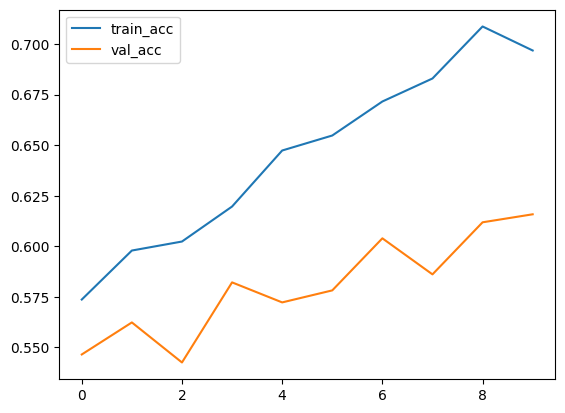

In [20]:
# Visualize training and validation scores
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show();

## **Convert the model to TensorFlow Lite**

In [21]:
# Save the model
model.save("trash_model.h5")

In [22]:
# Convert
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("trash_model.tflite", "wb") as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmpe4nqjbwg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  132967824584784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824587664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824586896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824588048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824588240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824588432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824586128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824586512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967824584592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132967782088784: TensorSpec(shape=(), dtype=tf.resource, name=None)


## **Test the TensorFlow Lite Model**

In [23]:
# Load TensforFlow Lite model
interpreter = tf.lite.Interpreter(model_path="trash_model.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [24]:
# Test the model on sample data
img_path = "/content/trash_dataset/TrashType_Image_Dataset/plastic/plastic_006.jpg"
img = Image.open(img_path).resize((128, 128))
input_img = np.expand_dims(np.array(img, dtype=np.float32) / 255.0, axis=0)

interpreter.set_tensor(input_details[0]['index'], input_img)
interpreter.invoke()
pred = interpreter.get_tensor(output_details[0]['index'])
print("Prediction:", np.argmax(pred), "Class names:", class_names)


Prediction: 2 Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


[Colab link](https://colab.research.google.com/drive/1JZdtRcnc-ME2ttUApuSjzY-jGu3Gl6Zk?usp=sharing)